In [20]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution

In [21]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [22]:
image_cut = image[55:155, 0:1800]
image_error_cut = image_error[55:155, 0:1800]

Text(0.5, 0, 'wavelenght')

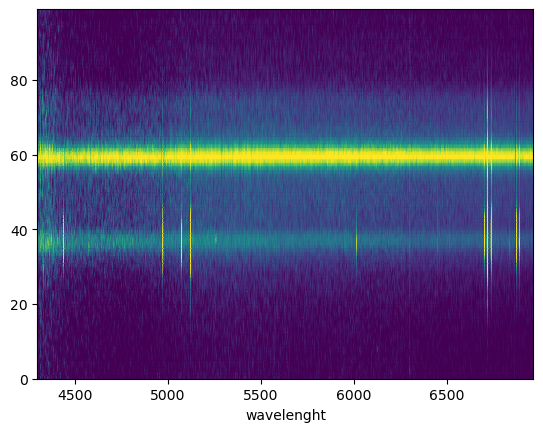

In [23]:
wv = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [24]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

Text(0.5, 1.0, 'H$\\alpha$')

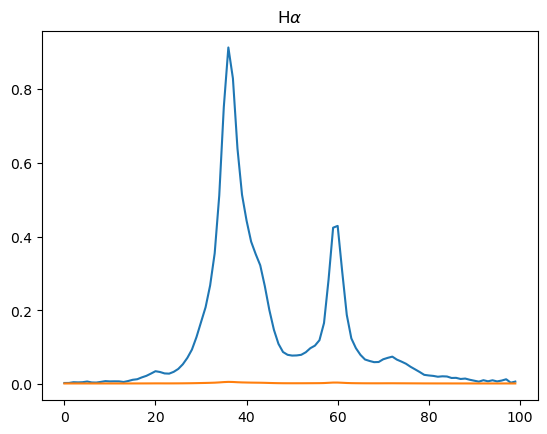

In [25]:
mask_HA = (wavelenghts > l_HA-10)*(wavelenghts < l_HA+10)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.mean(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))/image_error_HA.shape[1]

x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

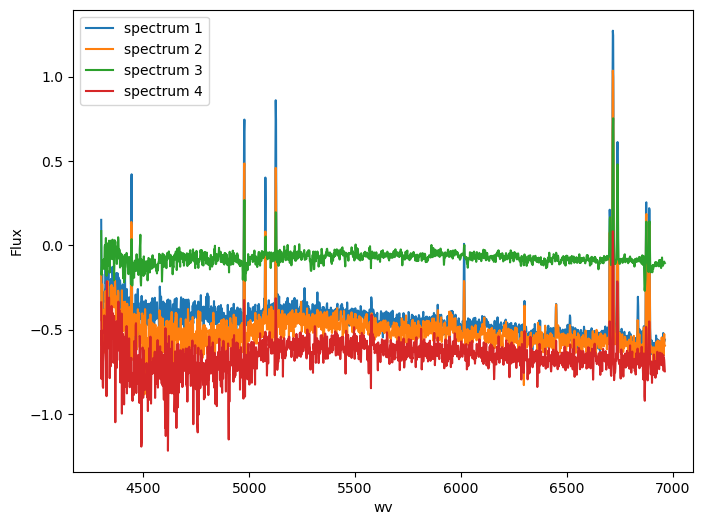

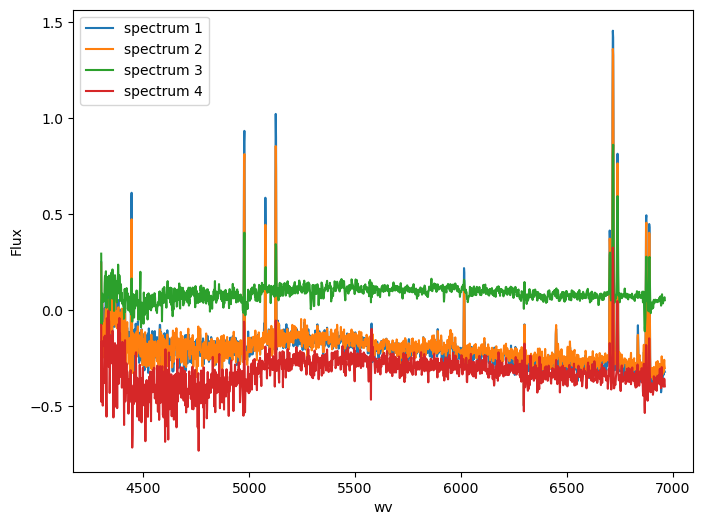

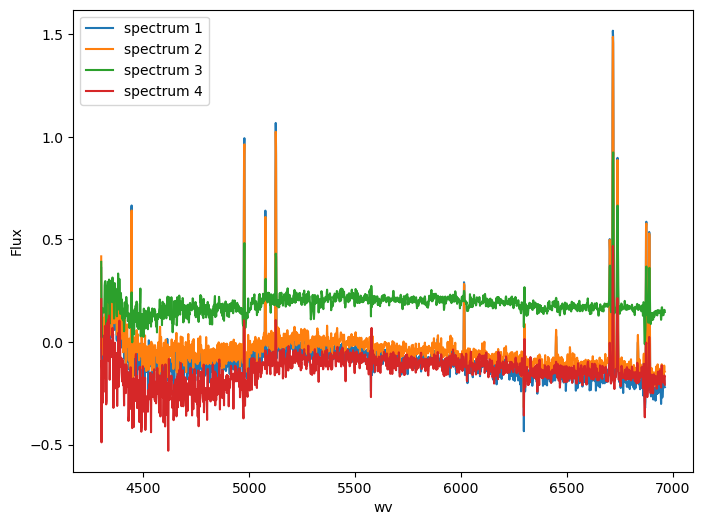

In [35]:
seeing = 3.17 #in pixels
peaks = [36.18, 42.10, 59.56, 72.21]

plt.figure(figsize=(8,6))
spectra_1 =  np.zeros((len(peaks), image_cut.shape[1]))
data1 = []
#Cut one sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-seeing)*(x_axes < peaks[i]+seeing)
    spectra_1[i] = np.sum(image_cut[mask, :], axis = 0)
    plt.plot(wv, np.log10(spectra_1[i]), label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel('wv')
    plt.ylabel('Flux')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_1[i].reshape(-1, 1)), axis=1)
    data1.append(spectrum_table)
    
np.savetxt('Spectra1s_1', data1[0])
np.savetxt('Spectra1s_2', data1[1])
np.savetxt('Spectra1s_3', data1[2])
np.savetxt('Spectra1s_4', data1[0])

plt.figure(figsize=(8,6))
spectra_2 =  np.zeros((len(peaks), image_cut.shape[1]))
data2 = []
#Cut two sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-2*seeing)*(x_axes < peaks[i]+2*seeing)
    spectra_2[i] = np.sum(image_cut[mask, :], axis = 0)
    plt.plot(wv, np.log10(spectra_2[i]), label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel('wv')
    plt.ylabel('Flux')
    
    data2.append(np.concatenate((wv.reshape(-1, 1), 
                                    spectra_2[i].reshape(-1, 1)), axis=1))
    
np.savetxt('Spectra2s_1', data2[0])
np.savetxt('Spectra2s_2', data2[1])
np.savetxt('Spectra2s_3', data2[2])
np.savetxt('Spectra2s_4', data2[0])

plt.figure(figsize=(8,6))
spectra_3 =  np.zeros((len(peaks), image_cut.shape[1]))
data3 = []
#Cut three sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-3*seeing)*(x_axes < peaks[i]+3*seeing)
    spectra_3[i] = np.sum(image_cut[mask, :], axis = 0)
    plt.plot(wv, np.log10(spectra_3[i]), label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel('wv')
    plt.ylabel('Flux')
    
    data3.append(np.concatenate((wv.reshape(-1, 1), 
                                    spectra_3[i].reshape(-1, 1)), axis=1))
    
np.savetxt('Spectra3s_1', data3[0])
np.savetxt('Spectra3s_2', data3[1])
np.savetxt('Spectra3s_3', data3[2])
np.savetxt('Spectra3s_4', data3[0])

In [27]:
data1

[array([[4.30074000e+03, 1.41456389e+00],
        [4.30222000e+03, 5.16845524e-01],
        [4.30370000e+03, 4.26110357e-01],
        ...,
        [6.96030000e+03, 2.68229157e-01],
        [6.96178000e+03, 2.72098213e-01],
        [6.96326000e+03, 2.75708735e-01]]),
 array([[4.30074000e+03, 6.80390298e-01],
        [4.30222000e+03, 3.56433064e-01],
        [4.30370000e+03, 3.59476358e-01],
        ...,
        [6.96030000e+03, 2.97505051e-01],
        [6.96178000e+03, 2.51867354e-01],
        [6.96326000e+03, 2.53177255e-01]]),
 array([[4.30074000e+03, 1.21225262e+00],
        [4.30222000e+03, 6.68528914e-01],
        [4.30370000e+03, 7.19244003e-01],
        ...,
        [6.96030000e+03, 7.99744248e-01],
        [6.96178000e+03, 7.87688136e-01],
        [6.96326000e+03, 7.83370376e-01]]),
 array([[4.30074000e+03, 4.58143443e-01],
        [4.30222000e+03, 1.60955906e-01],
        [4.30370000e+03, 3.12165737e-01],
        ...,
        [6.96030000e+03, 2.07739145e-01],
        [6.9617800